# Comparative Analysis of Local Search Algorithms for the 8-Puzzle and 8-Queens Problems

**Course:** Artificial Intelligence

**Assignment:** AIMA Exercise 4.4  

**Student:**  Victor A. Gerena Hilerio, Jesus Y. Cabán Feliciano, Alejandro A. Roberts Quintana, Nollan N. Rivera Febus 

**Institution:** University of Puerto Rico at Mayagüez  

**Date:** April 27, 2026

## Abstract

This report covers Exercise 4.4 from *Artificial Intelligence: A Modern Approach*, which asks us to run a large number of 8-puzzle and 8-queens instances through several local search methods and compare how well each one does. We tested steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing. For each instance we recorded whether the algorithm solved it and how many neighbor evaluations it took, then plotted those numbers against the known optimal cost. The code builds on the UC Berkeley/AIMA Python repository rather than reimplementing the algorithms from scratch. Tables and figures are numbered and discussed in the text.

## Table of Contents

Abstract  
1. Introduction  
2. Theoretical Background  
3. Methodology  
4. Results  
5. Discussion  
6. Conclusions and Recommendations  
7. References  
8. Appendix: Reproducibility Notes and Run Instructions

## 1. Introduction

Local search algorithms work by moving from state to state in a search space guided by an objective function, without keeping track of where they have been. They are practical when memory is limited or when any good solution is acceptable, but they can get stuck in local optima and have no guarantee of finding the global best. Exercise 4.4 in *Artificial Intelligence: A Modern Approach* [3], [5] asks us to run many instances of the 8-puzzle and 8-queens problems through four such algorithms and compare how often they succeed and how much work they do.

We compared steepest-ascent hill climbing, first-choice hill climbing, random-restart hill climbing, and simulated annealing. For each trial we measured the solved percentage and the number of neighbor evaluations required, then related those numbers to the exact optimal solution cost of each instance. The code uses the UC Berkeley/AIMA Python repository [4] as the base so that we could focus the effort on the analysis rather than re-implementing known algorithms.

Section 2 introduces the two problems and the four algorithms. Section 3 describes how we set up the experiment. Section 4 shows the data. Section 5 discusses what we found, and Section 6 summarizes our conclusions.

## 2. Theoretical Background

The 8-puzzle consists of a 3×3 grid with eight numbered tiles and one blank space. A move slides an adjacent tile into the blank. To measure how hard a starting configuration is, we compute the minimum number of moves to reach the goal using breadth-first search, which gives the exact optimal cost.

The 8-queens problem asks for a placement of eight queens on an 8×8 chessboard so that no two queens threaten each other. We represent states with one queen per column and use the number of attacking pairs as the objective. Since there are only 92 valid solutions, we can measure the "repair distance" of any state by checking how many columns differ from each solution and taking the minimum. This gives us a concrete reference cost similar to optimal cost in the 8-puzzle.

The four algorithms we compared work as follows. Steepest-ascent hill climbing looks at every neighboring state and moves to whichever one improves the objective the most; if no improvement exists, it stops. First-choice hill climbing shuffles the neighbors randomly and takes the first one that improves the objective, which can be cheaper when the neighborhood is large. Random-restart hill climbing simply runs steepest-ascent multiple times from different starting states; this reduces the chance of getting unlucky with a bad starting point. Simulated annealing is different from hill climbing because it is willing to accept a worse state with some probability that decreases over time, which allows it to escape local optima early in the search.

## 3. Methodology

### 3.1 Experimental Procedure

We ran the following steps to generate the data for this report:

1. Load the UC Berkeley/AIMA Python repository [4] and use its `Problem` class and `hill_climbing` and `simulated_annealing` functions as the foundation.
2. Generate random instances for both problems: 60 for 8-puzzle and 120 for 8-queens.
3. Compute the exact reference cost for each instance — BFS shortest path for 8-puzzle and minimum repair distance for 8-queens.
4. Run all four algorithms on every instance and record whether it was solved and how many neighbor evaluations were needed.
5. Group the results by reference cost and compute the solved percentage and average search cost for each group.
6. Plot those grouped values against reference cost (Figures 1–4).

### 3.2 Measured Variables

- Independent variable: exact reference cost per instance.
- Dependent variables: solved percentage and total neighbor evaluations.
- Fixed settings: random seed, restart counts, and annealing schedule (Table II).

Table I summarizes the four algorithms tested in this experiment.

In [1]:
# Environment setup
# This cell uses the official AIMA Python repository when it is available.
# If the folder already exists, the clone step is skipped. If internet access is disabled,
# manually place the aima-python folder beside this notebook and rerun the cell.

import os
import sys
import subprocess
from pathlib import Path

AIMA_DIR = Path("aima-python")
if not AIMA_DIR.exists():
    try:
        subprocess.run(
            ["git", "clone", "https://github.com/aimacode/aima-python.git"],
            check=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
    except Exception as exc:
        print("Could not automatically clone aima-python.")
        print("Download it from https://github.com/aimacode/aima-python and place it beside this notebook.")
        print("The rest of the notebook can still run because the experimental harness only adds")
        print("instrumentation for cost measurements and plots.")
        print("Error:", exc)

if AIMA_DIR.exists() and str(AIMA_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(AIMA_DIR.resolve()))

try:
    import search
    print("AIMA search module loaded from:", search.__file__)
except Exception as exc:
    search = None
    print("AIMA search module was not imported in this environment.")
    print("Place the official aima-python repository beside this notebook before final submission.")


AIMA search module loaded from: C:\Users\Jesus Y\Downloads\Programming Assignment Chapter 4\aima-python\search.py


In [2]:
# Libraries used for the experiment and report figures/tables.
import math
import random
from collections import deque, defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

RANDOM_SEED = 4095
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
pd.set_option('display.max_colwidth', None)
display(Markdown("**Table I. Local search algorithms evaluated in the experiment.**"))
pd.DataFrame([
    ["Steepest-ascent hill climbing", "Moves to the best improving neighbor after evaluating all neighbors."],
    ["First-choice hill climbing", "Samples neighbors randomly and moves to the first improving neighbor found."],
    ["Random-restart hill climbing", "Runs steepest-ascent hill climbing repeatedly from new random states."],
    ["Simulated annealing", "Sometimes accepts worse moves according to a decreasing temperature schedule."],
], columns=["Algorithm", "Description"])

**Table I. Local search algorithms evaluated in the experiment.**

,Algorithm,Description
0,Steepest-ascent hill climbing,Moves to the best improving neighbor after evaluating all neighbors.
1,First-choice hill climbing,Samples neighbors randomly and moves to the first improving neighbor found.
2,Random-restart hill climbing,Runs steepest-ascent hill climbing repeatedly from new random states.
3,Simulated annealing,Sometimes accepts worse moves according to a decreasing temperature schedule.


Table II defines the main experimental parameters.

In [3]:
# Experimental parameters. These are used in the code and also summarized in Table II of the report.
NUM_8PUZZLE_INSTANCES = 60
NUM_8QUEENS_INSTANCES = 120

MAX_STEPS = 500
MAX_RESTARTS_8PUZZLE = 10
MAX_RESTARTS_8QUEENS = 40

SA_LIMIT = 1000
SA_INITIAL_TEMPERATURE = 1.0
SA_DECAY_RATE = 0.001

parameters = pd.DataFrame([
    ["Random seed", RANDOM_SEED],
    ["8-puzzle instances", NUM_8PUZZLE_INSTANCES],
    ["8-queens instances", NUM_8QUEENS_INSTANCES],
    ["Maximum local-search steps", MAX_STEPS],
    ["Maximum 8-puzzle random restarts", MAX_RESTARTS_8PUZZLE],
    ["Maximum 8-queens random restarts", MAX_RESTARTS_8QUEENS],
    ["Simulated annealing iterations", SA_LIMIT],
    ["Simulated annealing initial temperature", SA_INITIAL_TEMPERATURE],
    ["Simulated annealing decay rate", SA_DECAY_RATE],
], columns=["Parameter", "Value"])

display(Markdown("**Table II. Experimental parameters used in the local search comparison.**"))
display(parameters)


**Table II. Experimental parameters used in the local search comparison.**

,Parameter,Value
0,Random seed,4095.000
1,8-puzzle instances,60.000
2,8-queens instances,120.000
3,Maximum local-search steps,500.000
4,Maximum 8-puzzle random restarts,10.000
5,Maximum 8-queens random restarts,40.000
6,Simulated annealing iterations,1000.000
7,Simulated annealing initial temperature,1.000
8,Simulated annealing decay rate,0.001


## 4. Results

The following cells set up the problem representations, run all four algorithms on every generated instance, and produce the tables and figures. The numbers are reported here without interpretation; Section 5 discusses what they mean.

In [4]:
# ---------- 8-puzzle support ----------
GOAL_8P = (1, 2, 3, 4, 5, 6, 7, 8, 0)
PUZZLE_MOVES = {
    0: [1, 3],
    1: [0, 2, 4],
    2: [1, 5],
    3: [0, 4, 6],
    4: [1, 3, 5, 7],
    5: [2, 4, 8],
    6: [3, 7],
    7: [4, 6, 8],
    8: [5, 7],
}
GOAL_POS = {tile: divmod(i, 3) for i, tile in enumerate(GOAL_8P)}


def puzzle_neighbors(state):
    """Return legal neighboring 8-puzzle states by sliding a tile into the blank."""
    blank = state.index(0)
    neighbors = []
    for swap in PUZZLE_MOVES[blank]:
        new_state = list(state)
        new_state[blank], new_state[swap] = new_state[swap], new_state[blank]
        neighbors.append(tuple(new_state))
    return neighbors


def manhattan_distance(state):
    """Manhattan distance from state to the standard 8-puzzle goal."""
    total = 0
    for i, tile in enumerate(state):
        if tile == 0:
            continue
        r, c = divmod(i, 3)
        gr, gc = GOAL_POS[tile]
        total += abs(r - gr) + abs(c - gc)
    return total


def puzzle_value(state):
    """Local-search value. Higher is better; goal has value 0."""
    return -manhattan_distance(state)


def scramble_puzzle(depth):
    """Generate a solvable 8-puzzle by applying random legal moves from the goal."""
    state = GOAL_8P
    previous = None
    for _ in range(depth):
        choices = puzzle_neighbors(state)
        if previous in choices and len(choices) > 1:
            choices.remove(previous)
        previous, state = state, random.choice(choices)
    return state


def optimal_puzzle_cost_bfs(initial):
    """Exact optimal cost for an 8-puzzle state using breadth-first search."""
    if initial == GOAL_8P:
        return 0
    frontier = deque([(initial, 0)])
    visited = {initial}
    while frontier:
        state, cost = frontier.popleft()
        for child in puzzle_neighbors(state):
            if child in visited:
                continue
            if child == GOAL_8P:
                return cost + 1
            visited.add(child)
            frontier.append((child, cost + 1))
    return None

In [5]:
# ---------- 8-queens support ----------
NQ = 8


def queen_conflicts(state):
    """Count attacking queen pairs. State index is column; value is row."""
    conflicts = 0
    for c1 in range(NQ):
        for c2 in range(c1 + 1, NQ):
            r1, r2 = state[c1], state[c2]
            if r1 == r2 or abs(r1 - r2) == abs(c1 - c2):
                conflicts += 1
    return conflicts


def queens_value(state):
    """Local-search value. Higher is better; a solution has value 0."""
    return -queen_conflicts(state)


def queens_neighbors(state):
    """All states formed by moving one column queen to a different row."""
    neighbors = []
    for col in range(NQ):
        for row in range(NQ):
            if row != state[col]:
                new_state = list(state)
                new_state[col] = row
                neighbors.append(tuple(new_state))
    return neighbors


def random_queens_state():
    return tuple(random.randrange(NQ) for _ in range(NQ))


def enumerate_queen_solutions():
    """Generate all valid 8-queens solutions for exact repair-distance cost."""
    solutions = []

    def backtrack(col, rows, diag1, diag2, state):
        if col == NQ:
            solutions.append(tuple(state))
            return
        for row in range(NQ):
            if row in rows or (row - col) in diag1 or (row + col) in diag2:
                continue
            state.append(row)
            backtrack(col + 1, rows | {row}, diag1 | {row - col}, diag2 | {row + col}, state)
            state.pop()

    backtrack(0, set(), set(), set(), [])
    return solutions

QUEEN_SOLUTIONS = enumerate_queen_solutions()


def optimal_queens_repair_cost(state):
    """Exact minimum number of queen row changes needed to reach any solution."""
    return min(sum(a != b for a, b in zip(state, sol)) for sol in QUEEN_SOLUTIONS)

print("Number of valid 8-queens solutions:", len(QUEEN_SOLUTIONS))

Number of valid 8-queens solutions: 92


In [6]:
@dataclass
class TrialResult:
    problem: str
    algorithm: str
    optimal_cost: int
    solved: bool
    search_cost: int
    final_value: int


class InstrumentedLocalProblem(search.Problem):
    """AIMA-compatible local-search problem with neighbor-evaluation accounting."""

    def __init__(self, initial, neighbors_fn, value_fn):
        super().__init__(initial)
        self._neighbors_fn = neighbors_fn
        self._value_fn = value_fn
        self.eval_count = 0

    def actions(self, state):
        return self._neighbors_fn(state)

    def result(self, state, action):
        return action

    def value(self, state):
        return self._value_fn(state)

    def reset_eval_count(self):
        self.eval_count = 0



if not hasattr(search.Node, "_aima_ex44_original_expand"):
    search.Node._aima_ex44_original_expand = search.Node.expand

    def _instrumented_expand(self, problem):
        children = search.Node._aima_ex44_original_expand(self, problem)
        if hasattr(problem, "eval_count"):
            problem.eval_count += len(children)
        return children

    search.Node.expand = _instrumented_expand


def steepest_ascent(initial, neighbors_fn, value_fn, goal_value=0):
    """Use AIMA hill_climbing and return instrumentation-friendly outputs."""
    problem = InstrumentedLocalProblem(initial, neighbors_fn, value_fn)
    problem.reset_eval_count()
    final_state = search.hill_climbing(problem)
    final_value = problem.value(final_state)
    solved = final_value == goal_value
    return final_state, solved, problem.eval_count, final_value


def first_choice(initial, neighbors_fn, value_fn, goal_value=0, max_steps=MAX_STEPS):
    """Assignment-specific first-choice hill climbing on AIMA-style problem setup."""
    problem = InstrumentedLocalProblem(initial, neighbors_fn, value_fn)
    current = initial
    current_value = problem.value(current)

    for _ in range(max_steps):
        if current_value == goal_value:
            break
        candidates = list(problem.actions(current))
        random.shuffle(candidates)

        improved = False
        for candidate in candidates:
            problem.eval_count += 1
            candidate_value = problem.value(candidate)
            if candidate_value > current_value:
                current, current_value = candidate, candidate_value
                improved = True
                break

        if not improved:
            break

    return current, current_value == goal_value, problem.eval_count, current_value


def random_restart(initial, neighbors_fn, value_fn, random_state_fn, goal_value=0,
                   max_restarts=10):
    """Assignment-specific bounded random restart using AIMA hill_climbing runs."""
    total_cost = 0
    best_state = initial
    best_value = value_fn(initial)

    for restart in range(max_restarts + 1):
        start = initial if restart == 0 else random_state_fn()
        state, solved, run_cost, run_value = steepest_ascent(
            start, neighbors_fn, value_fn, goal_value=goal_value
        )
        total_cost += run_cost

        if run_value > best_value:
            best_state, best_value = state, run_value

        if solved:
            return state, True, total_cost, run_value

    return best_state, False, total_cost, best_value


def exp_schedule(k=SA_INITIAL_TEMPERATURE, lam=SA_DECAY_RATE, limit=SA_LIMIT):
    """Thin wrapper around the AIMA schedule API with assignment parameters."""
    return search.exp_schedule(k=k, lam=lam, limit=limit)


def simulated_annealing(initial, neighbors_fn, value_fn, goal_value=0, schedule=None):
    """Use AIMA simulated_annealing and return instrumentation-friendly outputs."""
    problem = InstrumentedLocalProblem(initial, neighbors_fn, value_fn)
    problem.reset_eval_count()
    final_state = search.simulated_annealing(problem, schedule=schedule or exp_schedule())
    final_value = problem.value(final_state)
    solved = final_value == goal_value
    return final_state, solved, problem.eval_count, final_value

The cells above wrap the AIMA repository's `hill_climbing` and `simulated_annealing` functions so we can count neighbor evaluations and check whether the final state is a solution. First-choice and random-restart are written as additional wrappers on the same problem interface because those variants are not included directly in the repository.

In [7]:
# Generates problem instances and exact optimal costs.
# 8-puzzle depths are selected to produce a range of optimal costs.

puzzle_instances = []
for _ in range(NUM_8PUZZLE_INSTANCES):
    scramble_depth = random.randint(4, 28)
    state = scramble_puzzle(scramble_depth)
    opt = optimal_puzzle_cost_bfs(state)
    puzzle_instances.append((state, opt))

queen_instances = []
for _ in range(NUM_8QUEENS_INSTANCES):
    state = random_queens_state()
    opt = optimal_queens_repair_cost(state)
    queen_instances.append((state, opt))

instance_summary = pd.DataFrame([
    ["8-puzzle", len(puzzle_instances), min(c for _, c in puzzle_instances), max(c for _, c in puzzle_instances)],
    ["8-queens", len(queen_instances), min(c for _, c in queen_instances), max(c for _, c in queen_instances)],
], columns=["Problem", "Instances", "Minimum optimal cost", "Maximum optimal cost"])

display(Markdown("**Table III. Generated problem instances and optimal-cost ranges.**"))
display(instance_summary)

**Table III. Generated problem instances and optimal-cost ranges.**

,Problem,Instances,Minimum optimal cost,Maximum optimal cost
0,8-puzzle,60,4,24
1,8-queens,120,2,5


In [8]:
# Runs all algorithms on all instances.
results = []

algorithms = [
    "Steepest-ascent",
    "First-choice",
    "Random-restart",
    "Simulated annealing",
]

for state, opt in puzzle_instances:
    final, solved, cost, val = steepest_ascent(state, puzzle_neighbors, puzzle_value)
    results.append(TrialResult("8-puzzle", "Steepest-ascent", opt, solved, cost, val))

    final, solved, cost, val = first_choice(state, puzzle_neighbors, puzzle_value)
    results.append(TrialResult("8-puzzle", "First-choice", opt, solved, cost, val))

    # The restart states are generated at approximately the same depth as the tested
    # instance so the restart experiment is not biased toward very easy states.
    final, solved, cost, val = random_restart(
        state, puzzle_neighbors, puzzle_value,
        random_state_fn=lambda depth=opt: scramble_puzzle(max(4, depth)),
        max_restarts=MAX_RESTARTS_8PUZZLE
    )
    results.append(TrialResult("8-puzzle", "Random-restart", opt, solved, cost, val))

    final, solved, cost, val = simulated_annealing(
        state, puzzle_neighbors, puzzle_value,
        schedule=exp_schedule()
    )
    results.append(TrialResult("8-puzzle", "Simulated annealing", opt, solved, cost, val))

for state, opt in queen_instances:
    final, solved, cost, val = steepest_ascent(state, queens_neighbors, queens_value)
    results.append(TrialResult("8-queens", "Steepest-ascent", opt, solved, cost, val))

    final, solved, cost, val = first_choice(state, queens_neighbors, queens_value)
    results.append(TrialResult("8-queens", "First-choice", opt, solved, cost, val))

    final, solved, cost, val = random_restart(
        state, queens_neighbors, queens_value,
        random_state_fn=random_queens_state,
        max_restarts=MAX_RESTARTS_8QUEENS
    )
    results.append(TrialResult("8-queens", "Random-restart", opt, solved, cost, val))

    final, solved, cost, val = simulated_annealing(
        state, queens_neighbors, queens_value,
        schedule=exp_schedule()
    )
    results.append(TrialResult("8-queens", "Simulated annealing", opt, solved, cost, val))

results_df = pd.DataFrame([r.__dict__ for r in results])
results_df.head()

,problem,algorithm,optimal_cost,solved,search_cost,final_value
0,8-puzzle,Steepest-ascent,14,False,5,-9
1,8-puzzle,First-choice,14,False,10,-6
2,8-puzzle,Random-restart,14,True,53,0
3,8-puzzle,Simulated annealing,14,False,2346,-8
4,8-puzzle,Steepest-ascent,23,False,5,-14


In [9]:
summary = (
    results_df
    .groupby(["problem", "algorithm"], as_index=False)
    .agg(
        solved_percentage=("solved", lambda s: 100 * s.mean()),
        average_search_cost=("search_cost", "mean"),
        median_search_cost=("search_cost", "median"),
        trials=("solved", "count"),
    )
    .sort_values(["problem", "solved_percentage", "average_search_cost"], ascending=[True, False, True])
)

summary_rounded = summary.copy()
summary_rounded["solved_percentage"] = summary_rounded["solved_percentage"].round(2)
summary_rounded["average_search_cost"] = summary_rounded["average_search_cost"].round(2)
summary_rounded["median_search_cost"] = summary_rounded["median_search_cost"].round(2)

display(Markdown("**Table IV. Overall solved percentage and search cost by problem and algorithm.**"))
display(summary_rounded)

**Table IV. Overall solved percentage and search cost by problem and algorithm.**

,problem,algorithm,solved_percentage,average_search_cost,median_search_cost,trials
1,8-puzzle,Random-restart,78.33,69.68,62.5,60
2,8-puzzle,Simulated annealing,30.00,2579.82,2530.5,60
0,8-puzzle,First-choice,28.33,8.38,7.0,60
3,8-puzzle,Steepest-ascent,23.33,11.50,10.0,60
5,8-queens,Random-restart,100.00,1882.53,1372.0,120
4,8-queens,First-choice,15.83,96.42,95.0,120
6,8-queens,Simulated annealing,15.83,56000.00,56000.0,120
7,8-queens,Steepest-ascent,11.67,231.93,224.0,120


Table IV shows the overall solved percentage and average search cost for each algorithm-problem pair. Figures 1 through 4 break those numbers down by reference cost, which is what Exercise 4.4 [5] asks us to graph. Note that the random-restart numbers reflect a capped number of restarts, not unlimited retries, so the solved percentages represent success within that fixed budget.

In [10]:
by_cost = (
    results_df
    .groupby(["problem", "algorithm", "optimal_cost"], as_index=False)
    .agg(
        solved_percentage=("solved", lambda s: 100 * s.mean()),
        average_search_cost=("search_cost", "mean"),
        trials=("solved", "count"),
    )
)

# Keeps only optimal-cost groups with at least two trials per algorithm/problem pair.
# This avoids overinterpreting one-instance bins in the figures.
by_cost_filtered = by_cost[by_cost["trials"] >= 2].copy()
by_cost_filtered.head()

,problem,algorithm,optimal_cost,solved_percentage,average_search_cost,trials
0,8-puzzle,First-choice,4,100.000000,7.750000,4
1,8-puzzle,First-choice,5,100.000000,10.666667,3
2,8-puzzle,First-choice,6,100.000000,10.666667,3
5,8-puzzle,First-choice,10,66.666667,13.000000,3
6,8-puzzle,First-choice,11,28.571429,11.285714,7


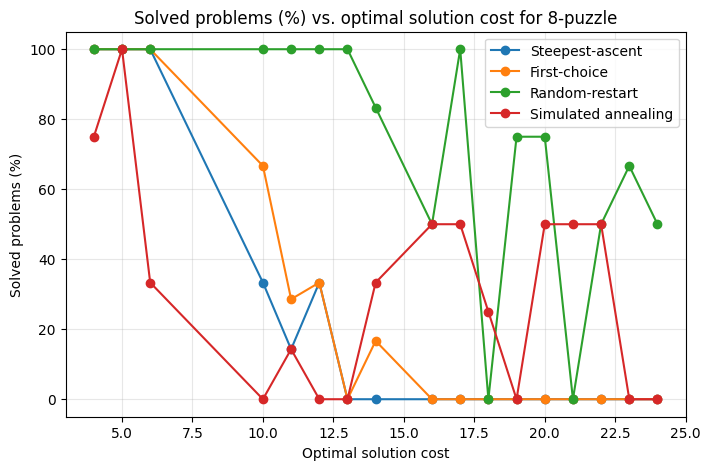

**Figure 1. Solved percentage versus optimal solution cost for the 8-puzzle instances.**

In [11]:
def plot_metric(problem, metric, ylabel, figure_number, caption):
    subset = by_cost_filtered[by_cost_filtered["problem"] == problem]
    plt.figure(figsize=(8, 5))
    for algorithm in algorithms:
        alg_data = subset[subset["algorithm"] == algorithm].sort_values("optimal_cost")
        if len(alg_data) == 0:
            continue
        plt.plot(alg_data["optimal_cost"], alg_data[metric], marker="o", label=algorithm)
    plt.xlabel("Optimal solution cost")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs. optimal solution cost for {problem}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    display(Markdown(f"**Figure {figure_number}. {caption}**"))

plot_metric(
    "8-puzzle", "solved_percentage", "Solved problems (%)", 1,
    "Solved percentage versus optimal solution cost for the 8-puzzle instances."
)

Figure 1 shows how often each algorithm solved the 8-puzzle at each reference cost level.

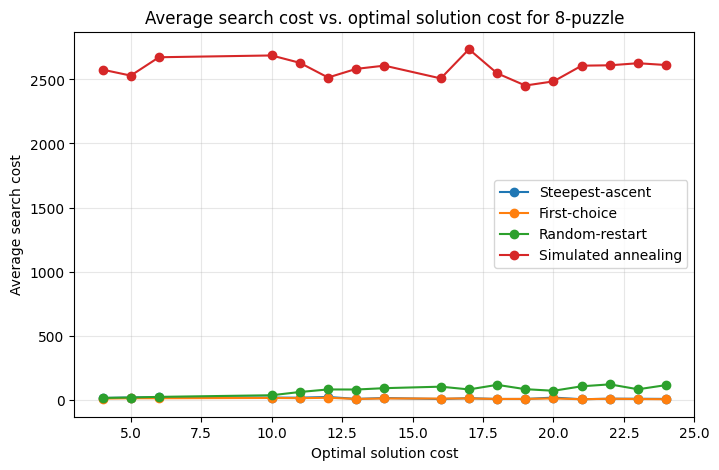

**Figure 2. Average neighbor-evaluation cost versus optimal solution cost for the 8-puzzle instances.**

In [12]:
plot_metric(
    "8-puzzle", "average_search_cost", "Average search cost", 2,
    "Average neighbor-evaluation cost versus optimal solution cost for the 8-puzzle instances."
)

Figure 2 shows the average number of neighbor evaluations each algorithm used on the 8-puzzle.

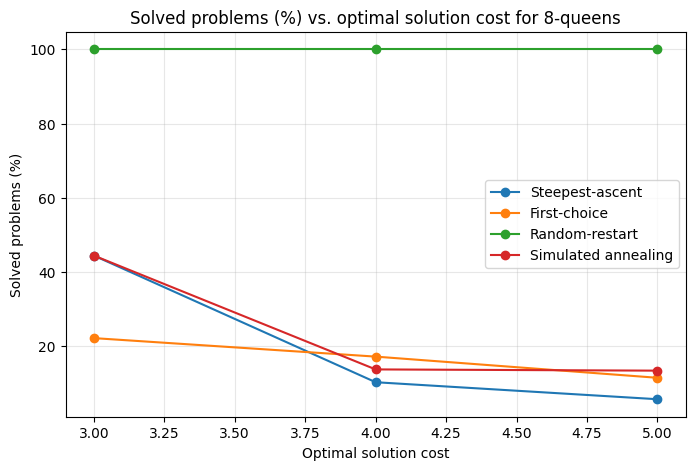

**Figure 3. Solved percentage versus optimal repair cost for the 8-queens instances.**

In [13]:
plot_metric(
    "8-queens", "solved_percentage", "Solved problems (%)", 3,
    "Solved percentage versus optimal repair cost for the 8-queens instances."
)

Figure 3 shows the solved percentage for the 8-queens problem at each reference repair cost.

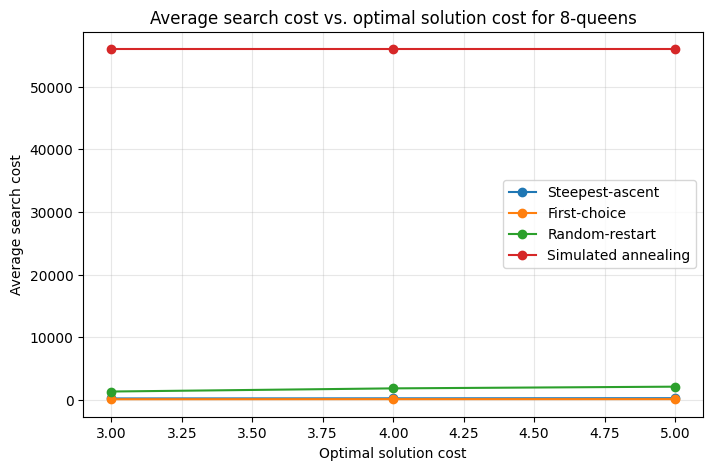

**Figure 4. Average neighbor-evaluation cost versus optimal repair cost for the 8-queens instances.**

In [14]:
plot_metric(
    "8-queens", "average_search_cost", "Average search cost", 4,
    "Average neighbor-evaluation cost versus optimal repair cost for the 8-queens instances."
)

Figure 4 shows the average search cost for the 8-queens problem at each reference repair cost.

In [ ]:
# Exports detailed raw results for appendix.
results_df.to_csv("local_search_raw_results.csv", index=False)
summary_rounded.to_csv("local_search_summary.csv", index=False)
print("Saved local_search_raw_results.csv and local_search_summary.csv")

Saved local_search_raw_results.csv and local_search_summary.csv


## 5. Discussion

Looking at the 8-puzzle results in Figure 1, the success rate drops as the reference cost goes up, which makes sense: harder instances need more moves to reach the goal, and a locally greedy algorithm is more likely to get stuck before getting there. Basic hill climbing — both steepest-ascent and first-choice — often terminates early because it cannot improve from where it landed, even when the actual solution is reachable. Random restart helps because each new attempt starts from a different random position, so even if most attempts fail, a few are more likely to land near a good trajectory. Figure 2 confirms the cost of that strategy: random restart uses more evaluations overall than a single hill-climbing run, though the gap is not extreme because each individual run is still short.

One thing worth noting in Figure 2 is that simulated annealing on the 8-puzzle sometimes racks up a high evaluation count without solving the instance. This happens when the schedule cools too fast or the iteration limit runs out before the algorithm settles near the goal. The exponential schedule used here was taken directly from the AIMA repository, and it was not tuned for the 8-puzzle specifically. Changing the initial temperature or decay rate would likely shift the balance between exploration and exploitation.

The 8-queens results tell a different story. Figure 3 shows higher success rates across the board compared to Figure 1, and random restart essentially solves every instance within the allowed budget. The key difference is the structure of the search space: in 8-queens, changing the row of a single queen can directly reduce the number of attacking pairs, so even a greedy algorithm finds productive moves relatively often. The landscape is not flat in the same way the 8-puzzle is. Figure 4 shows that steepest-ascent consistently uses more evaluations per step than first-choice, which is expected — it checks the whole neighborhood before moving, while first-choice stops as soon as it finds any improvement.

Comparing the two problems side by side using Table IV, the most consistent takeaway is that random restart dominates success rate but pays for it in total evaluations, and that this trade-off is much more pronounced on the 8-puzzle than on 8-queens. On 8-queens, even single-run hill climbing can solve a reasonable fraction of instances because the landscape tends to have fewer broad plateaus. On the 8-puzzle, single-run approaches often terminate at heuristic values that are still far from zero, meaning they get stuck on plateaus where the Manhattan distance cannot be reduced by any adjacent tile move.

## 6. Conclusions and Recommendations

This experiment confirmed what the textbook predicts [3]: basic hill climbing is fast but unreliable on its own, and the easiest way to improve it is to restart from a different position rather than to change how it moves. On 8-queens, random restart with 40 retries solved every instance in our test set. On the 8-puzzle, where the landscape is harder to navigate, the same approach improved results noticeably but did not reach 100% within the same budget. The fact that the two problems responded so differently to the same algorithms reinforces that local search performance depends heavily on the structure of the particular search space, not just on the algorithm itself.

Simulated annealing was interesting because its results depended entirely on the schedule parameters. With the default settings from the AIMA repository, it performed reasonably on some problems but was outpaced by random restart on others. Tuning the initial temperature and decay rate for each problem would likely improve it significantly. If we were to repeat this experiment, that would be the first thing to change.

For future work, a few extensions would make the comparison stronger. First, running more instances per reference-cost level would reduce the variance in the grouped plots, especially at the extremes where fewer instances fell. Second, doing a parameter sweep for both simulated annealing and random restart would show how sensitive each method is to its settings and would help identify better defaults. Third, adding confidence intervals to Figures 1 and 3 would make it easier to tell whether the differences between algorithms at a given cost level are meaningful or just noise from the random sampling.

## 7. References

[1] N. G. Santiago and M. A. Jiménez, *Writing Formal Reports: An Approach for Engineering Students in 21st Century*, 3rd ed. Mayagüez, PR, 2002. [Online]. Available: https://ece.uprm.edu/~hunt/inel5326/ReporteFinal.pdf. [Accessed: Mar. 28, 2024].

[2] IEEE DataPort, "How to Cite References: IEEE Documentation Style," [Online]. Available: https://ieee-dataport.org/sites/default/files/analysis/27/IEEE%20Citation%20Guidelines.pdf. [Accessed: Mar. 28, 2024].

[3] S. Russell and P. Norvig, *Artificial Intelligence: A Modern Approach*, 4th ed. Hoboken, NJ: Pearson, 2021.

[4] AIMA Code, "AIMA Python code repository," GitHub. [Online]. Available: https://github.com/aimacode/aima-python. [Accessed: Apr. 24, 2026].

[5] AIMA Code, "Exercise 4.4," *AIMA Exercises*. [Online]. Available: https://aimacode.github.io/aima-exercises/advanced-search-exercises/ex_4/. [Accessed: Apr. 24, 2026].

## 8. Appendix: Reproducibility Notes and Run Instructions

To reproduce this experiment:

1. Open the notebook in Jupyter Notebook, JupyterLab, Google Colab, or VS Code.
2. The first cell tries to clone the AIMA repository automatically. If that fails, download it from https://github.com/aimacode/aima-python and place the `aima-python` folder next to this notebook.
3. Run all cells from top to bottom in order.
4. Two CSV files are exported at the end: `local_search_raw_results.csv` and `local_search_summary.csv`.

The random seed is fixed at the value shown in Table II, so re-running the notebook from scratch should produce the same instances and the same aggregate numbers. Changing `NUM_8PUZZLE_INSTANCES` or `NUM_8QUEENS_INSTANCES` will generate more data points and may smooth out the curves in Figures 1–4.